In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
import pickle

from matplotlib.colors import LogNorm
#

In [2]:
fold_list = ["_dataij_hunit_TSC_cosmo_I_E1_v1.5_ini4/imex_ARK4(3)6L[2]SA_256_5e-05/",\
             "_dataij_hunit_TSC_cosmo_I_projRlx_E1_v1.5_ini4/imex_ARK4(3)6L[2]SA_256_5e-05/"]
folder = fold_list[0]
with open(folder+"case_dict.pkl", 'rb') as file:
    data = pickle.load(file)
    print(data.keys())
folder_relax = fold_list[1]
with open(folder_relax+"case_dict.pkl", 'rb') as file:
    data_relax = pickle.load(file)
    print(data_relax.keys())

dict_keys(['scheme', 'frame_list', 't_list', 'X', 'Xi', 'kappa', 'dt', 'm', 'mass_err_l', 'energy_err_l', 'mass_fdm', 'hbar_by_m', 'omega_m', 'energy_type', 'vapower'])
dict_keys(['scheme', 'frame_list', 't_list', 'X', 'Xi', 'kappa', 'dt', 'm', 'mass_err_l', 'energy_err_l', 'energy_err_loc_l', 'mass_fdm', 'hbar_by_m', 'omega_m', 'energy_type', 'vapower'])


(12,) (12,)
[0.         0.00010294 0.00027845 0.00027845 0.00027847 0.00027884
 0.00028292 0.00028694 0.0002893  0.00029049 0.00029102 0.00029125]


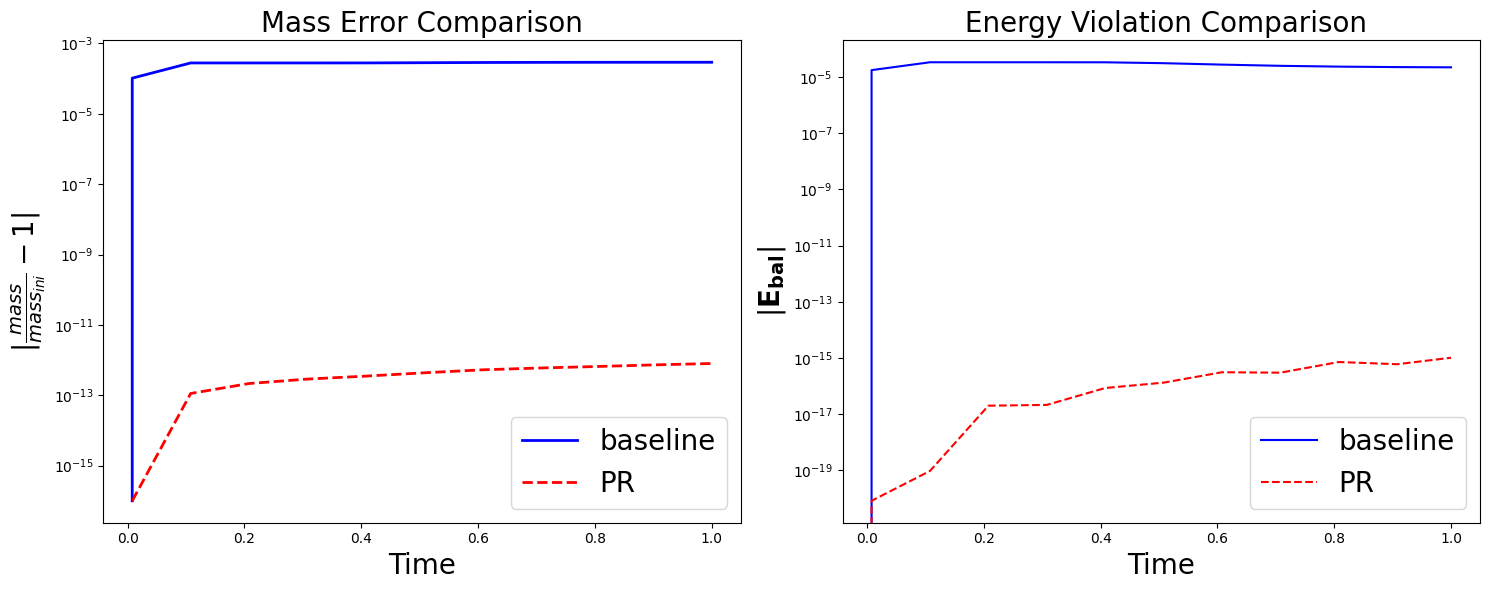

In [3]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

mass_err_l = np.abs(np.array(data['mass_err_l']))
energy_violation = np.abs(np.array(data['energy_err_l']))
mass_err_l_relax = np.abs(np.array(data_relax['mass_err_l']))
energy_violation_relax = np.abs(np.array(data_relax['energy_err_l']))
print(energy_violation.shape,energy_violation_relax.shape)




fig = plt.figure(figsize=(15, 6))
gs = gridspec.GridSpec(1, 2, figure=fig)


ax1 = fig.add_subplot(gs[0, 0])  
ax1.plot(data['t_list'][:], mass_err_l[:]+1e-16,linewidth=2,color="blue",label ="baseline")
ax1.plot(data_relax['t_list'][:], mass_err_l_relax[:]+1e-16,"--",linewidth=2, color="red", label="PR")

ax1.set_yscale('log')
ax1.set_xlabel('Time',fontsize=20)
ax1.set_ylabel(r"$|\frac{mass}{mass_{ini}}-1|$",fontsize=20)
ax1.legend(fontsize=20)
ax1.set_title('Mass Error Comparison',fontsize=20)


ax2 = fig.add_subplot(gs[0, 1])  
ax2.plot(data['t_list'][:], energy_violation[:],color="blue",label ="baseline")
ax2.plot(data_relax['t_list'][:], energy_violation_relax[:],"--", color="red", label="PR")
ax2.set_yscale('log')
ax2.set_xlabel('Time',fontsize=20)
ax2.set_ylabel("$|\mathbf{E_{bal}}|$",fontsize=20)
ax2.legend(fontsize=20)
ax2.set_title(' Energy Violation Comparison',fontsize=20)

plt.tight_layout()
plt.savefig("./figures_cosmo_3d/cosmo_3d_mass_energy.pdf",dpi=300,bbox_inches='tight')

print(mass_err_l)

dict_keys(['scheme', 'frame_list', 't_list', 'X', 'Xi', 'kappa', 'dt', 'm', 'mass_err_l', 'energy_err_l', 'mass_fdm', 'hbar_by_m', 'omega_m', 'energy_type', 'vapower']) (256, 256, 256)
dict_keys(['scheme', 'frame_list', 't_list', 'X', 'Xi', 'kappa', 'dt', 'm', 'mass_err_l', 'energy_err_l', 'energy_err_loc_l', 'mass_fdm', 'hbar_by_m', 'omega_m', 'energy_type', 'vapower']) (256, 256, 256)
[0.2078, 1.0] [0.2078, 1.0]
Loading frames for times: 0.2078 0.2078
cnt: 0 0.2078 3.8123195380173245
Loading frames for times: 1.0 1.0
cnt: 1 1.0 0.0


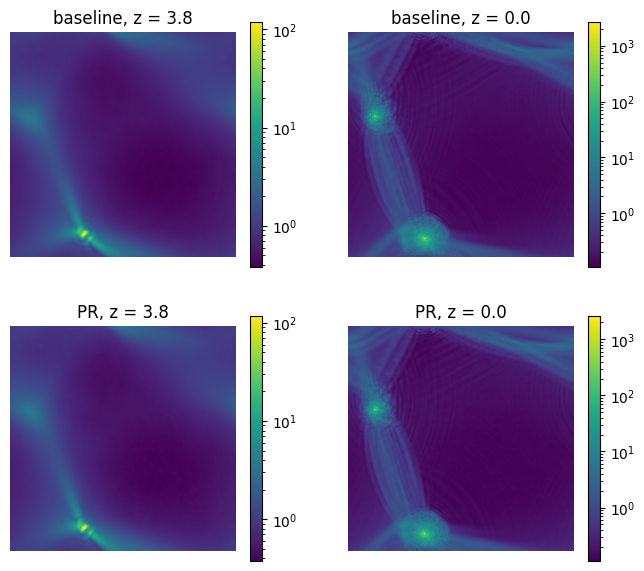

In [4]:
############ Relaxed vs Non-Relaxed ############
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cbook as cbook
import matplotlib.colors as colors
fold_list = ["_dataij_hunit_TSC_cosmo_I_E1_v1.5_ini4/imex_ARK4(3)6L[2]SA_256_5e-05/","_dataij_hunit_TSC_cosmo_I_projRlx_E1_v1.5_ini4/imex_ARK4(3)6L[2]SA_256_5e-05/"]

folder_0 = fold_list[0]
folder_1 = fold_list[1]


folder_case_0 = folder_0 + "case_dict.pkl"
folder_case_1 = folder_1 + "case_dict.pkl"


with open(folder_case_0, 'rb') as file:
    data_0 = pickle.load(file)
    m = data_0["frame_list"][0].shape
    print(data_0.keys(),m)

with open(folder_case_1, 'rb') as file:
    data_1 = pickle.load(file)
    m_1 = data_1["frame_list"][0].shape
    print(data_1.keys(),m_1)





i_list_0 = ["0.2078","1.0"]
i_list_1 = ["0.2078","1.0"]
t_list_0 = [float(i) if i!="initial" else 0.0078125 for i in i_list_0]
t_list_1 = [float(i) if i!="initial" else 0.0078125 for i in i_list_1]
print(t_list_0,t_list_1)



file_n_0 = folder_0+"frame_"
file_n_1 = folder_1+"frame_"



p_axis=2
xlim = 0.5
cmap = plt.get_cmap('coolwarm')

fig = plt.figure(figsize=(4*len(i_list_0), 7))
gs = gridspec.GridSpec(2, len(i_list_0), figure=fig)

i2j=-1


cnt = 0
for i0,i1 in zip(i_list_0,i_list_1):
   

    
    
    print("Loading frames for times:",i0,i1)
    frame_0 = np.load(file_n_0 + str(i0) + ".npz")['frame']
    mass_0 = np.mean(np.square(np.abs(frame_0)))
    
    frame_1 = np.load(file_n_1 + str(i1) + ".npz")['frame']
    mass_1 = np.mean(np.square(np.abs(frame_1)))




    ax = fig.add_subplot(gs[0, i_list_0.index(i0)])
    Z = np.square(np.abs(frame_0))
    proj_Z = np.mean(Z,axis=p_axis)
    pclm = ax.imshow(proj_Z,norm=LogNorm(vmin=proj_Z.min()+1e-14, vmax=proj_Z.max()))
    t=t_list_0[cnt]
    red_z = 1.0/t-1.0
    print("cnt:",cnt,t,red_z)
      
    fig.colorbar(pclm,ax=ax)
    ax.set_title("baseline, z = "+str(red_z)[:3])
    ax.set_box_aspect(1)
    ax.axis("off")


    ax2 = fig.add_subplot(gs[1, i_list_1.index(i1)])
    ax2.set_box_aspect(1)
    Z = np.square(np.abs(frame_1))
    proj_Z = np.mean(Z,axis=p_axis)
    mass = np.mean(Z)
    pclm = ax2.imshow(proj_Z,norm=LogNorm(vmin=proj_Z.min()+1e-14, vmax=proj_Z.max()))
    t=t_list_1[cnt]
    red_z = 1.0/t-1.0
    fig.colorbar(pclm,ax=ax2)
 
    ax2.set_title("PR, z = "+str(red_z)[:3])
    ax2.axis("off")

    
    cnt += 1
plt.savefig("./figures_cosmo_3d/cosmo_3d_density.pdf",dpi=300,bbox_inches='tight')









dict_keys(['scheme', 'frame_list', 't_list', 'X', 'Xi', 'kappa', 'dt', 'm', 'mass_err_l', 'energy_err_l', 'mass_fdm', 'hbar_by_m', 'omega_m', 'energy_type', 'vapower']) (256, 256, 256)
dict_keys(['scheme', 'frame_list', 't_list', 'X', 'Xi', 'kappa', 'dt', 'm', 'mass_err_l', 'energy_err_l', 'energy_err_loc_l', 'mass_fdm', 'hbar_by_m', 'omega_m', 'energy_type', 'vapower']) (256, 256, 256)
[0.0078125, 1.0] [0.0078125, 1.0]
Loading frames for times: initial initial
cnt: 0 0.0078125 127.0
Loading frames for times: 1.0 1.0
cnt: 1 1.0 0.0 2536.353048877392


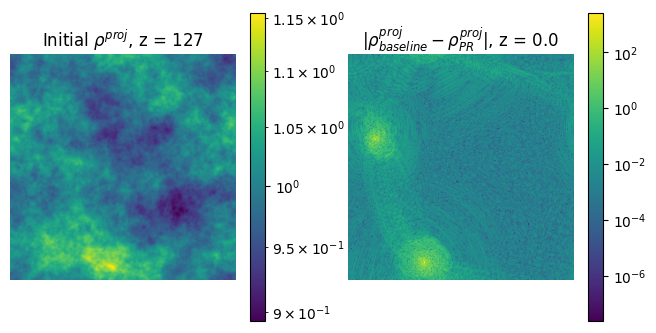

In [5]:
############ Relaxed vs Non-Relaxed ############
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cbook as cbook
import matplotlib.colors as colors
fold_list = ["_dataij_hunit_TSC_cosmo_I_E1_v1.5_ini4/imex_ARK4(3)6L[2]SA_256_5e-05/","_dataij_hunit_TSC_cosmo_I_projRlx_E1_v1.5_ini4/imex_ARK4(3)6L[2]SA_256_5e-05/"]

folder_0 = fold_list[0]
folder_1 = fold_list[1]

folder_case_0 = folder_0 + "case_dict.pkl"
folder_case_1 = folder_1 + "case_dict.pkl"


with open(folder_case_0, 'rb') as file:
    data_0 = pickle.load(file)
    m = data_0["frame_list"][0].shape
    print(data_0.keys(),m)

with open(folder_case_1, 'rb') as file:
    data_1 = pickle.load(file)
    m_1 = data_1["frame_list"][0].shape
    print(data_1.keys(),m_1)




# with open(folder_mass_relax_case, 'rb') as file:
#     data_mass_relax = pickle.load(file)
#     m_mass = data_mass_relax["frame_list"][0].shape
   


# i_list_0 = ["initial","0.2078","1.0"]#list(range(0,len(data['t_list'])-1))
# i_list_1 = ["initial","0.2078","1.0"]

i_list_0 = ["initial","1.0"]#list(range(0,len(data['t_list'])-1))
i_list_1 = ["initial","1.0"]
t_list_0 = [float(i) if i!="initial" else 0.0078125 for i in i_list_0]
t_list_1 = [float(i) if i!="initial" else 0.0078125 for i in i_list_1]
print(t_list_0,t_list_1)






file_n_0 = folder_0+"frame_"
file_n_1 = folder_1+"frame_"




p_axis=2
xlim = 0.5
cmap = plt.get_cmap('coolwarm')

fig = plt.figure(figsize=(8, 4))
gs = gridspec.GridSpec(1, 2, figure=fig)
#plt.xlim([-xlim,xlim])
#plt.ylim([-xlim,xlim])
i2j=-1


cnt = 0
for i0,i1 in zip(i_list_0,i_list_1):
   

    
    
    print("Loading frames for times:",i0,i1)
    frame_0 = np.load(file_n_0 + str(i0) + ".npz")['frame']
    mass_0 = np.mean(np.square(np.abs(frame_0)))
    
    frame_1 = np.load(file_n_1 + str(i1) + ".npz")['frame']
    mass_1 = np.mean(np.square(np.abs(frame_1)))

    Z = np.square(np.abs(frame_0))
    proj_Z = np.mean(Z,axis=p_axis)


    Z_PR = np.square(np.abs(frame_1))
    proj_Z_PR = np.mean(Z_PR,axis=p_axis)

    if cnt==0:
        ax = fig.add_subplot(gs[0, 0])
    
        pclm = ax.imshow(proj_Z,norm=LogNorm(vmin=proj_Z.min()+1e-14, vmax=proj_Z.max()))
        t=t_list_0[cnt]
        red_z = 1.0/t-1.0
        print("cnt:",cnt,t,red_z)
      
        fig.colorbar(pclm,ax=ax)
        ax.set_title("Initial "+r"$\rho^{proj}$"+", z = "+str(red_z)[:3])
        ax.set_box_aspect(1)
        ax.axis("off")
    else:
        diff = np.abs(proj_Z-proj_Z_PR)
        ax = fig.add_subplot(gs[0, 1])
    
        pclm = ax.imshow(diff,norm=LogNorm(vmin=diff.min()+1e-14, vmax=diff.max()))
        t=t_list_0[cnt]
        red_z = 1.0/t-1.0
        print("cnt:",cnt,t,red_z,np.max(diff))
      
        fig.colorbar(pclm,ax=ax)
        ax.set_title(r"$|\rho^{proj}_{baseline}-\rho^{proj}_{PR}|$"+", z = "+str(red_z)[:3])
        ax.set_box_aspect(1)
        ax.axis("off")






    
    cnt += 1
plt.savefig("./figures_cosmo_3d/cosmo_3d_density_initial.pdf",dpi=300,bbox_inches='tight')
  

    







